<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>Lecture 6: 实验 </B></font></td></tr></table>

# 应用beautifulsoup解析东方财富股吧评论数据

## 实验目标
1. 使用requests库下载东方财富股吧的评论数据
2. 使用BeautifulSoup解析HTML内容
3. 提取评论信息并存储到字典和列表中
4. 打印提取的数据
5. 总结实验工作

## 具体要求
- 自由选择1家感兴趣的上市公司；
- 下载该公司的东方财富股吧前3页的评论（建议使用requests库），并使用beautifulsoup解析各个html。
- 将每条评论的内容保持到字典中，key包括title、author、read(也就是阅读量)；
- 将所有的评论保存到列表中；
- 将所有评论打印(print)出来；
- 要总结实验工作；
- 不要删除我给出的必要函数定义和函数名称，可以完善我给出的函数。



**提交作业：**
- 在线提交：http://swufe.fanya.chaoxing.com/portal
- 截止日期：2025年10月22日晚上8点
- 仅仅提交**这个jupyter文档**，命名为“lecture5_experiment_你的学号+姓名.ipynb”，其中学号和姓名请替换为你自己的学号和姓名。
- 解析后的数据仅仅打印出来，不用保存到文件中。

**提示：**
- 东方财富股吧的URL根据你选择的公司有差异，这里用贵州茅台评论举例说明：以贵州茅台（600519）为例，评论第一页URL：https://guba.eastmoney.com/list,600519.html
第二页：https://guba.eastmoney.com/list,600519_2.html
第三页：https://guba.eastmoney.com/list,600519_3.html

**下周我们邀请同学分享其完成作业的过程**

# 个人信息填写

In [1]:
name = input("请输入你的姓名：")
print(name)

张俊伟


In [2]:
student_id = input("请输入你的学号：")
print(student_id)


42427086


## 第1步：导入必要的库

In [3]:
import requests
from bs4 import BeautifulSoup
import time
import random

## 第2步：定义目标公司并生成采集目标链接

###选择公司：中国核建（601611）

###选择时间范围：2025年10月16日

###生成采集目标链接：
https://guba.eastmoney.com/list,601611.html

（上为首页，后续稍微改动即可）

## 第3步：定义数据获取函数

- 可以参考我课堂给出的网页数据下载代码
- 完善下面的代码（要去掉pass，并添加你自己的代码）

In [ ]:
def download_data(url: str) -> str:
    """
    下载指定URL的网页内容。
    
    参数:
    url (str): 要下载的网页URL。

    返回:
    str: 网页的HTML内容。
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                response.encoding = response.apparent_encoding
                return response.text
            else:
                print(f"请求失败，状态码: {response.status_code}")
        except requests.exceptions.RequestException as e:
            print(f"请求异常 (尝试 {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(random.uniform(2, 5))  # 等待时间稍长一些
                continue
        return ""

# 第4步：定义HTML解析函数

- 完善下面的代码（要去掉pass，并添加你自己的代码）

In [18]:
# 导入必要的库
import requests
from bs4 import BeautifulSoup
import time

# 定义解析函数，确保能提取作者信息
def parse_comments(html):
    """
    解析HTML页面内容，提取所有评论信息
    
    参数:
        html: 包含评论的HTML字符串
    
    返回:
        包含评论字典的列表，每个字典包含title、author、time和read信息
    """
    comments = []
    soup = BeautifulSoup(html, 'html.parser')
    
    # 查找所有评论项
    list_items = soup.find_all('tr', class_='listitem')
    
    for item in list_items:
        comment = {}
        
        # 提取标题
        title_div = item.find('div', class_='title')
        if title_div:
            title_link = title_div.find('a')
            if title_link:
                comment['title'] = title_link.get_text(strip=True)
            else:
                comment['title'] = title_div.get_text(strip=True)
        else:
            comment['title'] = 'N/A'
        
        # 提取作者信息 - 修复版本，更灵活地匹配作者元素
        author_div = item.find('div', class_='author')
        if author_div:
            # 方法1：使用CSS选择器查找包含nametext类的a标签（更灵活）
            author_link = author_div.select_one('a[class*="nametext"]')
            
            # 如果方法1失败，尝试方法2：直接查找author div下的第一个a标签
            if not author_link:
                author_link = author_div.find('a')
            
            if author_link:
                comment['author'] = author_link.get_text(strip=True)
            else:
                comment['author'] = 'N/A'
        else:
            comment['author'] = 'N/A'
        
        # 提取时间信息
        time_div = item.find('div', class_=['update', 'mod_time'])
        if time_div:
            comment['time'] = time_div.get_text(strip=True)
        else:
            comment['time'] = 'N/A'
        
        # 提取阅读量
        read_div = item.find('div', class_='read')
        if read_div:
            comment['read'] = read_div.get_text(strip=True)
        else:
            comment['read'] = 'N/A'
        
        comments.append(comment)
    
    return comments



## 第5步：获取、解析并打印评论
- 应用上述变量和函数，获取、解析并打印前3页评论

In [19]:
# 定义要爬取的URL
target_stock = "601611"  # 中国核建的股票代码
all_comments = []

# 设置请求头，模拟浏览器访问
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'zh-CN,zh;q=0.8,zh-TW;q=0.7,zh-HK;q=0.5,en-US;q=0.3,en;q=0.2'
}

# 爬取前3页
for page in range(1, 4):
    try:
        # 修复URL构建，移除多余的反引号
        if page > 1:
            url = f"https://guba.eastmoney.com/list,{target_stock}_{page}.html"
        else:
            url = f"https://guba.eastmoney.com/list,{target_stock}.html"
        
        print(f"正在爬取第{page}页: {url}")
        
        # 发送请求
        response = requests.get(url, headers=headers, timeout=10)
        response.encoding = response.apparent_encoding
        
        # 检查响应状态
        if response.status_code != 200:
            print(f"警告: 第{page}页请求失败，状态码: {response.status_code}")
            continue
        
        # 解析评论
        page_comments = parse_comments(response.text)
        all_comments.extend(page_comments)
        
        print(f"第{page}页解析到{len(page_comments)}条评论")
        
        # 添加延时，避免请求过快被封
        time.sleep(2)
        
    except Exception as e:
        print(f"爬取第{page}页时出错: {str(e)}")
        # 出错时也添加延时
        time.sleep(2)

# 打印所有评论
print(f"\n总计解析到{len(all_comments)}条评论")

# 统计有作者信息的评论数量
has_author_count = sum(1 for comment in all_comments if comment['author'] != 'N/A')
print(f"成功提取到作者信息的评论: {has_author_count}条")

# 打印所有评论详情
for i, comment in enumerate(all_comments, 1):
    print(f"\n评论{i}:")
    print(f"标题: {comment['title']}")
    print(f"作者: {comment['author']}")
    print(f"时间: {comment['time']}")
    print(f"阅读量: {comment['read']}")

# 如果没有成功提取到作者信息，提供调试信息
if has_author_count == 0 and all_comments:
    print("\n警告: 未能提取到任何作者信息。可能的原因:")
    print("1. 网页结构可能已更改")
    print("2. 可能需要登录才能查看作者信息")
    print("3. 可能被网站识别为爬虫并限制了访问")
    print("\n建议: 尝试更新User-Agent或添加更多的请求头信息")

正在爬取第1页: https://guba.eastmoney.com/list,601611.html
第1页解析到80条评论
正在爬取第2页: https://guba.eastmoney.com/list,601611_2.html
第2页解析到80条评论
正在爬取第3页: https://guba.eastmoney.com/list,601611_3.html
第3页解析到80条评论

总计解析到240条评论
成功提取到作者信息的评论: 240条

评论1:
标题: 中核集团发布品牌战略 构建“一主多元”品牌架构
作者: 中国核建资讯
时间: 10-16 07:53
阅读量: 3039

评论2:
标题: 从仓位控制、板块选择、买卖时机等核心炒股环节发力，结合市场常见情况与风险防控要点
作者: 股友e96Q693353
时间: 10-16 09:21
阅读量: 1255

评论3:
标题: 盘后分析，明作方案！
作者: 我的日记2025
时间: 10-16 04:37
阅读量: 2947

评论4:
标题: 10.16复盘：送上我的“抗周期”能力清单 合锻智能 国光连锁 中G核建
作者: 老秦谈股论金
时间: 10-16 04:42
阅读量: 1879

评论5:
标题: 中阳修复，继续突破！卧龙电驱，中国核建，五洲新春
作者: 老散淡波势
时间: 10-16 05:37
阅读量: 1017

评论6:
标题: 明确提出"中国核建"是“中核集团"的七大战略品牌之一！牛！
作者: 基民Trs5EO
时间: 10-16 09:32
阅读量: 4

评论7:
标题: 核建今年的高点已过，后面就是调整，十元以下见
作者: 热情的夜清湖9
时间: 10-16 08:55
阅读量: 48

评论8:
标题: 参考沃尔核材开始下跌趋势
作者: 股友231893xa31
时间: 10-16 08:30
阅读量: 61

评论9:
标题: 明天涨停
作者: 温和友善的郑菡
时间: 10-16 09:22
阅读量: 11

评论10:
标题: 是重大利好吗？
作者: 温柔娴静的千帆4
时间: 10-16 09:03
阅读量: 845

评论11:
标题: 周四思路指数缩量阳线，轮动十几个方向，缺乏合力主升的持续性板块，难度还是不小。适
作者: 倩妹er
时间: 10-16 1

初始化分词工具...
正在加载评论数据...
成功读取数据，共2480条评论
正在分析评论数据...

评论总数: 2480

前10个高频词:
1. 今天: 222
2. 大盘: 163
3. 牛市: 158
4. 调整: 109
5. 指数: 103
6. 下跌: 91
7. 下午: 88
8. 结束: 70
9. 就是: 70
10. 反弹: 68

TF-IDF关键词:
牛市: 0.0982
今天: 0.0923
大盘: 0.0714
调整: 0.0438
下午: 0.0438
指数: 0.0419
下跌: 0.0401
散户: 0.0399
SH: 0.0388
个点: 0.0358

正在生成词云图...
词云图已保存至: stock_board_wordcloud.png


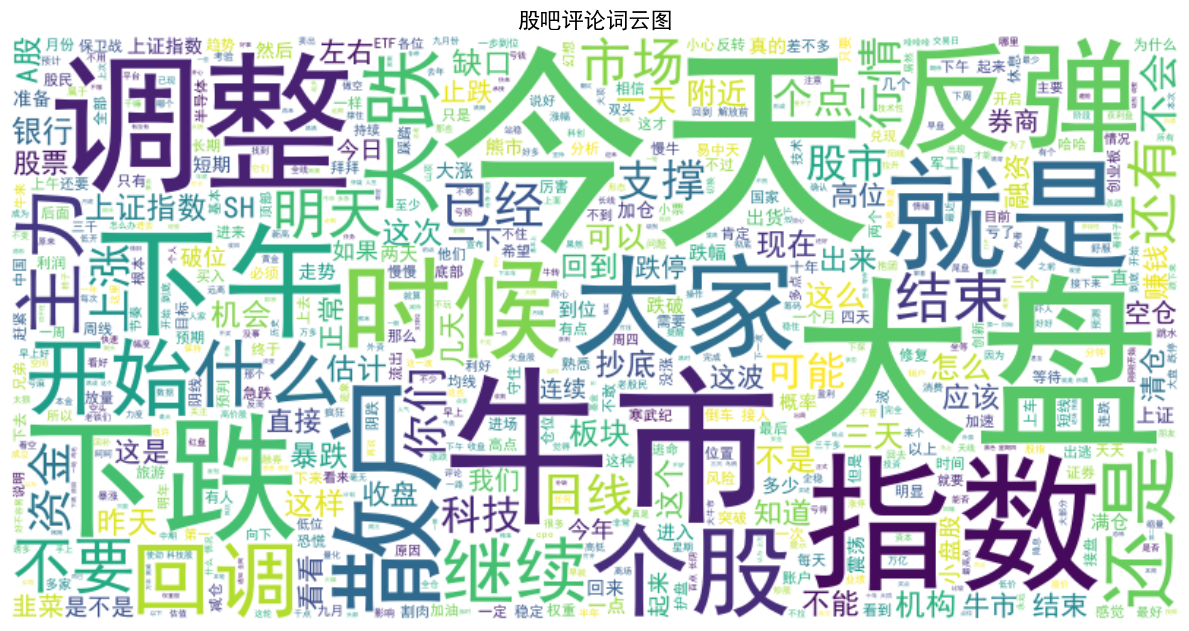


分析完成！


In [6]:
# -*- coding: utf-8 -*-
"""
评论分析与词云图生成

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jieba
import jieba.analyse
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import re
import warnings

# 忽略警告
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

def load_comments(file_path):
    """
    加载评论数据
    
    Args:
        file_path: 文件路径
    
    Returns:
        DataFrame: 评论数据
    """
    try:
        # 读取CSV文件
        df = pd.read_csv(file_path)
        print(f"成功读取数据，共{len(df)}条评论")
        return df
    except Exception as e:
        print(f"读取文件出错: {e}")
        return None

def preprocess_text(text):
    """
    文本预处理
    
    Args:
        text: 原始文本
    
    Returns:
        str: 处理后的文本
    """
    if not isinstance(text, str):
        return ''
    
    # 移除特殊字符和数字
    text = re.sub(r'[\d+\s+""\'\`\~\!\@\#\$\%\^\&\*\(\)\-\_\=\+\[\]\{\}\\|\;\:\'\"\,\.\<\>\/\?]', ' ', text)
    # 移除多余的空格
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def segment_words(text):
    """
    中文分词
    
    Args:
        text: 处理后的文本
    
    Returns:
        list: 分词结果
    """
    if not text:
        return []
    
    # 使用jieba进行分词
    words = jieba.cut(text)
    # 过滤停用词和单字
    stop_words = set(STOPWORDS)
    # 添加中文停用词
    additional_stopwords = {'的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一', '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '自己', '这'}
    stop_words.update(additional_stopwords)
    
    return [word for word in words if word not in stop_words and len(word) > 1]

def analyze_comments(df):
    """
    分析评论数据
    
    Args:
        df: 评论数据
    
    Returns:
        dict: 分析结果
    """
    if df is None or df.empty:
        return None
    
    # 确保标题列存在
    if '帖子标题' not in df.columns:
        print("数据中没有'帖子标题'列")
        return None
    
    # 文本预处理和分词
    df['处理后标题'] = df['帖子标题'].apply(preprocess_text)
    df['分词结果'] = df['处理后标题'].apply(segment_words)
    
    # 统计评论数量
    total_comments = len(df)
    
    # 统计不同股票吧的评论数
    if '股票吧名称' in df.columns:
        board_counts = df['股票吧名称'].value_counts().head(10)
    else:
        board_counts = None
    
    # 统计活跃用户
    if '用户昵称' in df.columns:
        active_users = df['用户昵称'].value_counts().head(10)
    else:
        active_users = None
    
    # 合并所有分词结果
    all_words = []
    for words in df['分词结果']:
        all_words.extend(words)
    
    # 生成词频统计
    word_freq = {}
    for word in all_words:
        if word in word_freq:
            word_freq[word] += 1
        else:
            word_freq[word] = 1
    
    # 排序词频
    sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    
    # 提取关键词（使用TF-IDF）
    all_text = ' '.join(df['处理后标题'])
    keywords_tfidf = jieba.analyse.extract_tags(all_text, topK=20, withWeight=True)
    
    return {
        'total_comments': total_comments,
        'board_counts': board_counts,
        'active_users': active_users,
        'all_words': all_words,
        'word_freq': dict(sorted_word_freq[:50]),  # 取前50个高频词
        'keywords_tfidf': keywords_tfidf
    }

def generate_wordcloud(text, output_path='wordcloud.png', mask_path=None):
    """
    生成词云图
    
    Args:
        text: 文本内容（空格分隔的词语）
        output_path: 输出路径
        mask_path: 蒙版图片路径
    
    Returns:
        bool: 是否成功
    """
    try:
        # 设置词云参数
        wc = WordCloud(
            font_path='simhei.ttf',  # 中文字体路径
            background_color='white',
            max_words=2000,
            max_font_size=150,
            random_state=42,
            width=800,
            height=400
        )
        
        # 如果有蒙版图片
        if mask_path:
            mask = np.array(Image.open(mask_path))
            wc = WordCloud(
                font_path='simhei.ttf',
                background_color='white',
                max_words=2000,
                max_font_size=150,
                random_state=42,
                mask=mask
            )
        
        # 生成词云
        wc.generate(text)
        
        # 显示词云
        plt.figure(figsize=(12, 8))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('股吧评论词云图', fontsize=16)
        
        # 保存词云图
        wc.to_file(output_path)
        print(f"词云图已保存至: {output_path}")
        
        # 显示图表
        plt.tight_layout()
        plt.show()
        
        return True
    except Exception as e:
        print(f"生成词云图出错: {e}")
        return False


def main():
    """
    主函数
    """
    # 文件路径（可以根据实际情况修改）
    file_path = 'e:/Study/2-1/finance_analysis/data/guba/sse_comments.csv'
    
    # 1. 加载数据
    print("正在加载评论数据...")
    df = load_comments(file_path)
    if df is None:
        print("无法加载数据，程序退出")
        return
    
    # 2. 数据分析
    print("正在分析评论数据...")
    analysis_results = analyze_comments(df)
    if analysis_results is None:
        print("分析数据失败，程序退出")
        return
    
    # 3. 显示分析结果
    print(f"\n评论总数: {analysis_results['total_comments']}")
    
    print("\n前10个高频词:")
    for i, (word, freq) in enumerate(list(analysis_results['word_freq'].items())[:10], 1):
        print(f"{i}. {word}: {freq}")
    
    print("\nTF-IDF关键词:")
    for word, weight in analysis_results['keywords_tfidf'][:10]:
        print(f"{word}: {weight:.4f}")
    
    
    # 5. 生成词云图
    print("\n正在生成词云图...")
    # 将所有词语用空格连接
    text_for_wordcloud = ' '.join(analysis_results['all_words'])
    generate_wordcloud(text_for_wordcloud, output_path='stock_board_wordcloud.png')
    
    print("\n分析完成！")

if __name__ == "__main__":
    # 确保jieba正确初始化
    print("初始化分词工具...")
    jieba.initialize()
    main()

## 实验工作总结
- 总结你的工作过程中遇到的问题；
- 解决问题的途径；
- 本次作业的收获心得；

#### 1、注意到builider暂时无法单独对jyputer中的代码单元格单独书写，可以考虑使用chat模式手动理解并完善代码。

#### 2、作者一直显示N/A，问题出在调用函数的部分代码，而非函数代码

##### 问题为作者的标签名为"nametext fl"而非“nametext”
解决方法为：
- 使用CSS选择器 a[class*="nametext"] 来查找类名中包含"nametext"的a标签，这样即使类名有额外的空格或其他类名，也能匹配到

- 添加了备用方案：如果第一个方法失败，直接查找author div下的第一个a标签


### 学习到了最基础的python爬虫，爬取了中国核建吧的前三页评论。后续需要学习如何应对其他的HTML界面与各类反爬虫机制。